# 招聘数据处理与整合

**处理目标：** 基于多 Sheet 字段对比分析，对招聘数据进行清洗、标准化和整合

**数据源：** `datas/src/招聘数据总表_2510.xlsx`

**输出：** 处理后的统一数据集

---

## 处理流程

1. **环境准备与数据加载**
2. **多 Sheet 字段对比分析**
3. **数据处理策略制定**
4. **字段标准化处理**
5. **数据整合与合并**
6. **数据质量验证**
7. **导出处理结果**


## 1. 环境准备与数据加载

**处理动机：** 导入必要的库并加载所有 Sheet 的数据，为后续处理做准备。


In [2]:
# 导入必要的库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
from datetime import datetime

# 设置显示选项
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', 50)

# 设置中文显示（macOS）
# plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 设置图表样式
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

# 忽略警告
warnings.filterwarnings('ignore')

print("✅ 环境准备完成！")
print(f"📅 处理开始时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")


✅ 环境准备完成！
📅 处理开始时间: 2025-10-14 10:00:21


In [3]:
# 这里用的是 SimHei 字体，可以根据自己的需要更改
from wanglaoshi import JupyterFont as JF
JF.matplotlib_font_init()

In [4]:
# 加载数据
file_path = 'datas/src/招聘数据总表_2510.xlsx'

print("📂 正在加载数据...")
print("=" * 80)

# 读取所有 sheet
excel_file = pd.ExcelFile(file_path)
sheet_names = excel_file.sheet_names

print(f"✓ 发现 {len(sheet_names)} 个工作表")

# 读取所有 sheet 到字典中
dfs = {}
for sheet in sheet_names:
    dfs[sheet] = pd.read_excel(file_path, sheet_name=sheet)
    print(f"  ✓ {sheet}: {dfs[sheet].shape[0]:,} 行 × {dfs[sheet].shape[1]} 列")

print("\n" + "=" * 80)
print("✅ 数据加载完成！")


📂 正在加载数据...
✓ 发现 8 个工作表
  ✓ 营销类: 8,702 行 × 19 列
  ✓ 运营类: 9,091 行 × 20 列
  ✓ 产品类: 7,026 行 × 20 列
  ✓ 管培类: 2,261 行 × 19 列
  ✓ 财会类: 4,851 行 × 19 列
  ✓ 编程类: 8,629 行 × 21 列
  ✓ 金融中台: 4,186 行 × 19 列
  ✓ 数据类: 6,583 行 × 15 列

✅ 数据加载完成！


## 2. 多 Sheet 字段对比分析

**处理动机：** 
- 理解所有 Sheet 的字段全集（最大整体集合）
- 分析每个 Sheet 的字段分布和覆盖情况
- 识别共同字段和独有字段
- 为数据整合策略提供依据


In [5]:
# 字段对比分析
print("📋 各 Sheet 字段对比分析")
print("=" * 80)

# 1. 获取所有 sheet 的字段并集（最大整体集合）
all_columns = set()
for sheet in sheet_names:
    all_columns.update(dfs[sheet].columns.tolist())

all_columns = sorted(list(all_columns))  # 排序便于查看

print(f"\n✓ 所有 Sheet 的字段并集: {len(all_columns)} 个字段")
print(f"  字段列表: {', '.join(all_columns[:10])}{'...' if len(all_columns) > 10 else ''}")

# 2. 创建字段对比矩阵
print(f"\n📊 字段存在性矩阵:")
print("=" * 80)

# 构建对比数据
field_comparison = []
for col in all_columns:
    row_data = {'字段名': col}
    for sheet in sheet_names:
        # 检查该字段是否存在于当前 sheet
        if col in dfs[sheet].columns:
            row_data[sheet] = '✓'
        else:
            row_data[sheet] = '✗'
    field_comparison.append(row_data)

comparison_df = pd.DataFrame(field_comparison)

# 显示完整的对比表
print(f"字段对比表（共 {len(comparison_df)} 个字段）：")
display(comparison_df)


📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 42 个字段
  字段列表: Unnamed: 0, 公司位置, 公司分级, 公司名称, 公司地址, 公司行业, 公司规模, 公司部门, 公司阶段, 学历要求...

📊 字段存在性矩阵:
字段对比表（共 42 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,Unnamed: 0,✗,✓,✗,✗,✗,✗,✗,✗
1,公司位置,✗,✓,✓,✓,✓,✓,✓,✓
2,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
3,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
4,公司地址,✓,✗,✗,✗,✗,✗,✗,✗
5,公司行业,✓,✗,✗,✗,✗,✗,✗,✗
6,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
7,公司部门,✓,✗,✗,✓,✗,✓,✗,✗
8,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
9,学历要求,✓,✓,✓,✓,✓,✓,✓,✓


In [6]:
# 3. 统计每个 Sheet 的字段覆盖情况
print(f"\n📈 各 Sheet 字段覆盖率:")
print("-" * 80)

coverage_stats = []
for sheet in sheet_names:
    sheet_cols = set(dfs[sheet].columns)
    coverage = len(sheet_cols) / len(all_columns) * 100
    unique_fields = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
    
    coverage_stats.append({
        'Sheet名称': sheet,
        '字段数': len(sheet_cols),
        '覆盖率(%)': f"{coverage:.1f}",
        '独有字段数': len(unique_fields),
        '独有字段': ', '.join(sorted(unique_fields)) if unique_fields else '无'
    })

coverage_df = pd.DataFrame(coverage_stats)
display(coverage_df)



📈 各 Sheet 字段覆盖率:
--------------------------------------------------------------------------------


,Sheet名称,字段数,覆盖率(%),独有字段数,独有字段
0,营销类,19,45.2,7,"公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求"
1,运营类,20,47.6,2,"Unnamed: 0, 工资月数"
2,产品类,20,47.6,3,"实习, 最低工资, 最高工资"
3,管培类,19,45.2,0,无
4,财会类,19,45.2,1,资
5,编程类,21,50.0,2,"平均薪资, 月.1"
6,金融中台,19,45.2,3,"平均年薪（千人名币）, 最低月薪（千人名币）, 最高月薪（千人名币）"
7,数据类,15,35.7,0,无


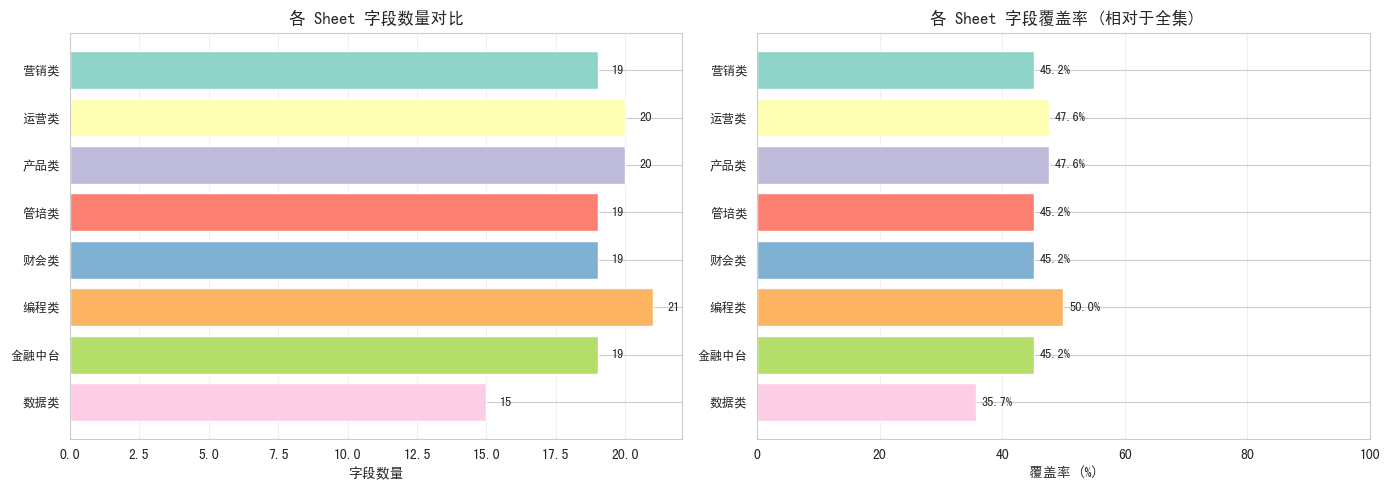

In [7]:
# 4. 可视化字段覆盖情况
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# 左图：各 Sheet 字段数量
sheet_field_counts = [len(dfs[s].columns) for s in sheet_names]
colors_palette = plt.cm.Set3(range(len(sheet_names)))

ax1.barh(range(len(sheet_names)), sheet_field_counts, color=colors_palette)
ax1.set_yticks(range(len(sheet_names)))
ax1.set_yticklabels(sheet_names, fontsize=9)
ax1.set_xlabel('字段数量', fontsize=10)
ax1.set_title('各 Sheet 字段数量对比', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(axis='x', alpha=0.3)

# 添加数值标签
for i, v in enumerate(sheet_field_counts):
    ax1.text(v + 0.5, i, str(v), va='center', fontsize=9)

# 右图：字段覆盖率
coverage_values = [float(c['覆盖率(%)']) for c in coverage_stats]

ax2.barh(range(len(sheet_names)), coverage_values, color=colors_palette)
ax2.set_yticks(range(len(sheet_names)))
ax2.set_yticklabels(sheet_names, fontsize=9)
ax2.set_xlabel('覆盖率 (%)', fontsize=10)
ax2.set_title('各 Sheet 字段覆盖率 (相对于全集)', fontsize=12, fontweight='bold')
ax2.set_xlim(0, 100)
ax2.invert_yaxis()
ax2.grid(axis='x', alpha=0.3)

# 添加百分比标签
for i, v in enumerate(coverage_values):
    ax2.text(v + 1, i, f'{v:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()


In [8]:
# 5. 找出共同字段和各自独有字段
print(f"\n🔍 字段集合分析:")
print("=" * 80)

# 共同字段（所有 sheet 都有的）
common_fields = set(dfs[sheet_names[0]].columns)
for sheet in sheet_names[1:]:
    common_fields &= set(dfs[sheet].columns)

print(f"\n✓ 共同字段 (所有 Sheet 都包含): {len(common_fields)} 个")
if common_fields:
    print(f"  {', '.join(sorted(common_fields))}")
else:
    print(f"  无")

# 各 Sheet 独有字段
print(f"\n✓ 各 Sheet 独有字段:")
unique_fields_by_sheet = {}
for sheet in sheet_names:
    sheet_cols = set(dfs[sheet].columns)
    unique = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
    unique_fields_by_sheet[sheet] = unique
    print(f"  • {sheet}: {len(unique)} 个")
    if unique:
        print(f"    {', '.join(sorted(unique))}")

print("\n" + "=" * 80)



🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 8 个
  公司分级, 公司名称, 公司规模, 公司阶段, 学历要求, 岗位名称, 岗位类型, 岗位要求

✓ 各 Sheet 独有字段:
  • 营销类: 7 个
    公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求
  • 运营类: 2 个
    Unnamed: 0, 工资月数
  • 产品类: 3 个
    实习, 最低工资, 最高工资
  • 管培类: 0 个
  • 财会类: 1 个
    资
  • 编程类: 2 个
    平均薪资, 月.1
  • 金融中台: 3 个
    平均年薪（千人名币）, 最低月薪（千人名币）, 最高月薪（千人名币）
  • 数据类: 0 个



## 3. 根据上面的分析结果给出具体的处理

### 3.1 营销类的处理


• 营销类: 7 个
    公司地址, 公司行业, 岗位福利, 岗位类别, 岗位薪资, 平均年薪/K, 经验要求

![076ftB](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/076ftB.png)

In [9]:
# 修改营销类 sheet 的列名：公司地址 -> 公司位置
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'公司地址': '公司位置'})
    print("✅ 已将'营销类' sheet 中的'公司地址'列名修改为'公司位置'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'公司地址'列名修改为'公司位置'


![dBoXt4](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/dBoXt4.png)

In [10]:
# 修改营销类 sheet 的列名：公司行业 -> 所处行业
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'公司行业': '所处行业'})
    print("✅ 已将'营销类' sheet 中的'公司行业'列名修改为'所处行业'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'公司行业'列名修改为'所处行业'


![6IzXw7](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/6IzXw7.png)

In [11]:
# 修改营销类 sheet 的列名：岗位福利 -> 岗位诱惑
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位福利': '岗位诱惑'})
    print("✅ 已将'营销类' sheet 中的'岗位福利'列名修改为'岗位诱惑'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位福利'列名修改为'岗位诱惑'


In [12]:
# 修改营销类 sheet 的列名：岗位类别 -> 岗位分类
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位类别': '岗位分类'})
    print("✅ 已将'营销类' sheet 中的'岗位类别'列名修改为'岗位分类'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位类别'列名修改为'岗位分类'


In [13]:
# 修改营销类 sheet 的列名：岗位薪资 -> 薪资
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'岗位薪资': '薪资'})
    print("✅ 已将'营销类' sheet 中的'岗位薪资'列名修改为'薪资'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'岗位薪资'列名修改为'薪资'


In [14]:
# 修改营销类 sheet 的列名：平均年薪/K -> 平均年薪
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'平均年薪/K': '平均年薪'})
    print("✅ 已将'营销类' sheet 中的'平均年薪/K'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'平均年薪/K'列名修改为'平均年薪'


In [15]:
# 修改营销类 sheet 的列名：经验要求 -> 状态要求
if '营销类' in dfs:
    dfs['营销类'] = dfs['营销类'].rename(columns={'经验要求': '状态要求'})
    print("✅ 已将'营销类' sheet 中的'经验要求'列名修改为'状态要求'")
else:
    print("⚠️  未找到'营销类' sheet")

✅ 已将'营销类' sheet 中的'经验要求'列名修改为'状态要求'


### 3.2 运营类的处理

 • 运营类: 2 个
    Unnamed: 0, 工资月数


![C8uxkU](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/C8uxkU.png)

In [16]:
# 删除运营类 sheet 的 Unnamed: 0 列
if '运营类' in dfs:
    if 'Unnamed: 0' in dfs['运营类'].columns:
        dfs['运营类'] = dfs['运营类'].drop(columns=['Unnamed: 0'])
        print("✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列")
    else:
        print("⚠️  '运营类' sheet 中未找到 'Unnamed: 0' 列")
else:
    print("⚠️  未找到'运营类' sheet")

✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列


In [17]:
# 修改运营类 sheet 的列名：工资月数 -> 薪资月
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'工资月数': '薪资月'})
    print("✅ 已将'运营类' sheet 中的'工资月数'列名修改为'薪资月'")
else:
    print("⚠️  未找到'运营类' sheet")

✅ 已将'运营类' sheet 中的'工资月数'列名修改为'薪资月'


### 3.3 产品类的处理

![yzovm5](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/yzovm5.png)

In [18]:
# 修改产品类 sheet 的列名：最低工资 -> 最低月薪; 最高工资 -> 最高月薪
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'最低工资': '最低月薪', '最高工资': '最高月薪'})  
    print("✅ 已将'产品类' sheet 中的'最低工资'列名修改为'最低月薪', '最高工资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'产品类' sheet")

✅ 已将'产品类' sheet 中的'最低工资'列名修改为'最低月薪', '最高工资'列名修改为'最高月薪'


### 3.4 财会类的处理

![HxFHlz](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/HxFHlz.png)

In [19]:
# 修改财会类 sheet 的列名：资 -> 薪资月
if '财会类' in dfs:
    dfs['财会类'] = dfs['财会类'].rename(columns={'资': '薪资月'})  
    print("✅ 已将'财会类' sheet 中的'资'列名修改为'薪资月'")
else:
    print("⚠️  未找到'财会类' sheet")

✅ 已将'财会类' sheet 中的'资'列名修改为'薪资月'


### 3.5 编程类的处理

编程类: 2 个
* 平均薪资, 
* 月.1

**平均薪资**是我们计划要增加的字段,所以现在先保留.

![Is7wUx](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/Is7wUx.png)

In [20]:
# 删除 编程类 sheet 里的 月 这个字段
if '编程类' in dfs:
    if '月' in dfs['编程类'].columns:
        dfs['编程类'] = dfs['编程类'].drop(columns=['月'])
        print("✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列")
    else:
        print("⚠️  '编程类' sheet 中未找到 '月' 列")
else:
    print("⚠️  未找到'编程类' sheet")
    
# 修改编程类 sheet 的列名：月.1 -> 月
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'月.1': '月'})
    print("✅ 已将'编程类' sheet 中的'月.1'列名修改为'月'")
else:
    print("⚠️  未找到'编程类' sheet")
    

✅ 已删除'运营类' sheet 中的 'Unnamed: 0' 列
✅ 已将'编程类' sheet 中的'月.1'列名修改为'月'


### 3.6 金融中台的处理

![Ck5cfz](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/Ck5cfz.png)

In [21]:
# 修改 金融中台 sheet 的列名：平均年薪（千人名币）-> 平均年薪, 最低月薪（千人名币）-> 最低月薪, 最高月薪（千人名币）-> 最高月薪
if '金融中台' in dfs:
    dfs['金融中台'] = dfs['金融中台'].rename(columns={'平均年薪（千人名币）': '平均年薪', '最低月薪（千人名币）': '最低月薪', '最高月薪（千人名币）': '最高月薪'})
    print("✅ 已将'金融中台' sheet 中的'平均年薪（千人名币）'列名修改为'平均年薪', '最低月薪（千人名币）'列名修改为'最低月薪', '最高月薪（千人名币）'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'金融中台' sheet")
    


✅ 已将'金融中台' sheet 中的'平均年薪（千人名币）'列名修改为'平均年薪', '最低月薪（千人名币）'列名修改为'最低月薪', '最高月薪（千人名币）'列名修改为'最高月薪'


## 4. 将 sheet 对比的方法复制过来封装为函数

In [22]:
def sheet_compare(dfs, sheet_names):
    # 5. 找出共同字段和各自独有字段
    print(f"\n🔍 字段集合分析:")
    print("=" * 80)

    # 共同字段（所有 sheet 都有的）
    common_fields = set(dfs[sheet_names[0]].columns)
    for sheet in sheet_names[1:]:
        common_fields &= set(dfs[sheet].columns)

    print(f"\n✓ 共同字段 (所有 Sheet 都包含): {len(common_fields)} 个")
    if common_fields:
        print(f"  {', '.join(sorted(common_fields))}")
    else:
        print(f"  无")

    # 各 Sheet 独有字段
    print(f"\n✓ 各 Sheet 独有字段:")
    unique_fields_by_sheet = {}
    for sheet in sheet_names:
        sheet_cols = set(dfs[sheet].columns)
        unique = sheet_cols - set().union(*[set(dfs[s].columns) for s in sheet_names if s != sheet])
        unique_fields_by_sheet[sheet] = unique
        print(f"  • {sheet}: {len(unique)} 个")
        if unique:
            print(f"    {', '.join(sorted(unique))}")

    print("\n" + "=" * 80)
    
    
    print("=" * 80)
    # 字段对比分析
    print("📋 各 Sheet 字段对比分析")
    print("=" * 80)

    # 1. 获取所有 sheet 的字段并集（最大整体集合）
    all_columns = set()
    for sheet in sheet_names:
        all_columns.update(dfs[sheet].columns.tolist())

    all_columns = sorted(list(all_columns))  # 排序便于查看

    print(f"\n✓ 所有 Sheet 的字段并集: {len(all_columns)} 个字段")
    print(f"  字段列表: {', '.join(all_columns[:10])}{'...' if len(all_columns) > 10 else ''}")

    # 2. 创建字段对比矩阵
    print(f"\n📊 字段存在性矩阵:")
    print("=" * 80)

    # 构建对比数据
    field_comparison = []
    for col in all_columns:
        row_data = {'字段名': col}
        for sheet in sheet_names:
            # 检查该字段是否存在于当前 sheet
            if col in dfs[sheet].columns:
                row_data[sheet] = '✓'
            else:
                row_data[sheet] = '✗'
        field_comparison.append(row_data)

    comparison_df = pd.DataFrame(field_comparison)

    # 显示完整的对比表
    print(f"字段对比表（共 {len(comparison_df)} 个字段）：")
    display(comparison_df)



In [23]:
sheet_compare(dfs, sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 14 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 所处行业, 状态要求, 薪资

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 1 个
    实习
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 1 个
    平均薪资
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 26 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 实习, 岗位分类, 岗位名称...

📊 字段存在性矩阵:
字段对比表（共 26 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✗,✗,✓,✗,✓,✗,✗
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,实习,✗,✗,✓,✗,✗,✗,✗,✗
8,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓


![ACkFZJ](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/ACkFZJ.png)

In [24]:
# 删除 产品类 sheet 的 实习 这个字段
if "产品类" in dfs:
    if "实习" in dfs["产品类"].columns:
        dfs["产品类"] = dfs["产品类"].drop(columns=["实习"])
        print("✅ 已删除'产品类' sheet 中的 '实习' 列")
    else:
        print("⚠️  '产品类' sheet 中未找到 '实习' 列")
else:
    print("⚠️  未找到'产品类' sheet")
    
# 修改 管培类 sheet 里的 岗位年薪 -> 平均年薪
if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'岗位年薪': '平均年薪'})
    print("✅ 已将'管培类' sheet 中的'岗位年薪'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'管培类' sheet")
    
# 修改 编程类 sheet 里的 岗位年薪 -> 平均年薪
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'岗位年薪': '平均年薪'})
    print("✅ 已将'编程类' sheet 中的'岗位年薪'列名修改为'平均年薪'")
else:
    print("⚠️  未找到'编程类' sheet")
    
# 删除 编程类 sheet 的 平均薪资 这个字段
if '编程类' in dfs:
    if '平均薪资' in dfs['编程类'].columns:
        dfs['编程类'] = dfs['编程类'].drop(columns=['平均薪资'])
        print("✅ 已删除'编程类' sheet 中的 '平均薪资' 列")
    else:
        print("⚠️  '编程类' sheet 中未找到 '平均薪资' 列")

# 修改 运营类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'运营类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'运营类' sheet")

# 修改 管培类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'管培类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'管培类' sheet")
    
# 修改 编程类 sheet 的 最低薪资 -> 最低月薪; 最高薪资 -> 最高月薪
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'最低薪资': '最低月薪', '最高薪资': '最高月薪'})
    print("✅ 已将'编程类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'")
else:
    print("⚠️  未找到'编程类' sheet")

# 修改 产品类,管培类,编程类 sheet 里的 月  字段名 -> 薪资月
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'产品类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'产品类' sheet")

if '管培类' in dfs:
    dfs['管培类'] = dfs['管培类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'管培类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'管培类' sheet")
    
if '编程类' in dfs:
    dfs['编程类'] = dfs['编程类'].rename(columns={'月': '薪资月'})
    print("✅ 已将'编程类' sheet 中的'月'列名修改为'薪资月'")
else:
    print("⚠️  未找到'编程类' sheet")    
    

# 修改 运营类 sheet 里的 部门 -> 公司部门
if '运营类' in dfs:
    dfs['运营类'] = dfs['运营类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'运营类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'运营类' sheet")

# 修改 产品类 sheet 里的 部门 -> 公司部门
if '产品类' in dfs:
    dfs['产品类'] = dfs['产品类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'产品类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'产品类' sheet")
    
# 修改 财会类 sheet 里的 部门 -> 公司部门
if '财会类' in dfs:
    dfs['财会类'] = dfs['财会类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'财会类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'财会类' sheet")
    
# 修改 金融中台 sheet 里的 部门 -> 公司部门
if '金融中台' in dfs:
    dfs['金融中台'] = dfs['金融中台'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'金融中台' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'金融中台' sheet")
    
# 修改 数据类 sheet 里的 部门 -> 公司部门
if '数据类' in dfs:
    dfs['数据类'] = dfs['数据类'].rename(columns={'部门': '公司部门'})
    print("✅ 已将'数据类' sheet 中的'部门'列名修改为'公司部门'")
else:
    print("⚠️  未找到'数据类' sheet")


✅ 已删除'产品类' sheet 中的 '实习' 列
✅ 已将'管培类' sheet 中的'岗位年薪'列名修改为'平均年薪'
✅ 已将'编程类' sheet 中的'岗位年薪'列名修改为'平均年薪'
✅ 已删除'编程类' sheet 中的 '平均薪资' 列
✅ 已将'运营类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'管培类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'编程类' sheet 中的'最低薪资'列名修改为'最低月薪', '最高薪资'列名修改为'最高月薪'
✅ 已将'产品类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'管培类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'编程类' sheet 中的'月'列名修改为'薪资月'
✅ 已将'运营类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'产品类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'财会类' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'金融中台' sheet 中的'部门'列名修改为'公司部门'
✅ 已将'数据类' sheet 中的'部门'列名修改为'公司部门'


In [25]:
sheet_compare(dfs=dfs, sheet_names=sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 15 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 所处行业, 状态要求, 薪资

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 0 个
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 0 个
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 19 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型...

📊 字段存在性矩阵:
字段对比表（共 19 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✓,✓,✓,✓,✓,✓,✓
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
8,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位类型,✓,✓,✓,✓,✓,✓,✓,✓


![M2EHT4](https://upiclw.oss-cn-beijing.aliyuncs.com/uPic/M2EHT4.png)

In [26]:
# 3k-5k
# 30k-60k·13薪
# 8k-16k
# 7k-14k
# 15k-30k·14薪
# 13k-20k·13薪
# 12k-24k
# 14k-20k·16薪
# 15k-25k·14薪
# 18k-35k·14薪
# 30k-60k
# 25k-50k·15薪
# 20k-30k·13薪
# 15k-30k·16薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 20k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 20k-30k·14薪
# 15k-30k·16薪
# 15k-30k·15薪
# 15k-30k·15薪
# 16k-30k·16薪
# 15k-30k·14薪
# 15k-30k·14薪
# 15k-30k·16薪
# 将数据类 sheet 里的薪资字段 拆解为 最低月薪,最高月薪,薪资月,平均年薪

# 拆解薪资字段
import re

def parse_salary(salary_str):
    """
    解析薪资字符串，返回最低月薪、最高月薪、薪资月数、平均年薪
    例如: '15k-30k·14薪' -> (15, 30, 14, 315.0)
    """
    if pd.isna(salary_str):
        return None, None, None, None
    
    # 提取薪资范围 (例如: 15k-30k)
    salary_match = re.search(r'(\d+)k-(\d+)k', str(salary_str))
    if not salary_match:
        return None, None, None, None
    
    min_salary = int(salary_match.group(1))
    max_salary = int(salary_match.group(2))
    
    # 提取薪资月数 (例如: ·14薪)
    months_match = re.search(r'·(\d+)薪', str(salary_str))
    salary_months = int(months_match.group(1)) if months_match else 12
    
    # 计算平均年薪 (单位: 千元)
    avg_annual_salary = (min_salary + max_salary) / 2 * salary_months
    
    return min_salary, max_salary, salary_months, avg_annual_salary

# 应用到数据类 sheet（假设薪资字段名为"薪资"或类似）
if '数据类' in dfs:
    # 确定薪资字段名（可能是"薪资"、"月薪"等）
    salary_col = None
    for col in dfs['数据类'].columns:
        if '薪资' in col or '月薪' in col or '工资' in col:
            salary_col = col
            break
    
    if salary_col:
        # 应用解析函数
        result = dfs['数据类'][salary_col].apply(parse_salary)
        
        # 拆分为4列
        dfs['数据类']['最低月薪'] = result.apply(lambda x: x[0])
        dfs['数据类']['最高月薪'] = result.apply(lambda x: x[1])
        dfs['数据类']['薪资月'] = result.apply(lambda x: x[2])
        dfs['数据类']['平均年薪'] = result.apply(lambda x: x[3])
        
        print(f"✅ 已拆解'数据类' sheet 的'{salary_col}'字段")
        print(f"   新增列: 最低月薪, 最高月薪, 薪资月, 平均年薪")
    else:
        print("⚠️  未找到薪资相关字段")
else:
    print("⚠️  未找到'数据类' sheet")

✅ 已拆解'数据类' sheet 的'薪资'字段
   新增列: 最低月薪, 最高月薪, 薪资月, 平均年薪


In [27]:
sheet_compare(dfs=dfs,sheet_names=sheet_names)


🔍 字段集合分析:

✓ 共同字段 (所有 Sheet 都包含): 19 个
  公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型, 岗位要求, 岗位诱惑, 平均年薪, 所处行业, 最低月薪, 最高月薪, 状态要求, 薪资, 薪资月

✓ 各 Sheet 独有字段:
  • 营销类: 0 个
  • 运营类: 0 个
  • 产品类: 0 个
  • 管培类: 0 个
  • 财会类: 0 个
  • 编程类: 0 个
  • 金融中台: 0 个
  • 数据类: 0 个

📋 各 Sheet 字段对比分析

✓ 所有 Sheet 的字段并集: 19 个字段
  字段列表: 公司位置, 公司分级, 公司名称, 公司规模, 公司部门, 公司阶段, 学历要求, 岗位分类, 岗位名称, 岗位类型...

📊 字段存在性矩阵:
字段对比表（共 19 个字段）：


,字段名,营销类,运营类,产品类,管培类,财会类,编程类,金融中台,数据类
0,公司位置,✓,✓,✓,✓,✓,✓,✓,✓
1,公司分级,✓,✓,✓,✓,✓,✓,✓,✓
2,公司名称,✓,✓,✓,✓,✓,✓,✓,✓
3,公司规模,✓,✓,✓,✓,✓,✓,✓,✓
4,公司部门,✓,✓,✓,✓,✓,✓,✓,✓
5,公司阶段,✓,✓,✓,✓,✓,✓,✓,✓
6,学历要求,✓,✓,✓,✓,✓,✓,✓,✓
7,岗位分类,✓,✓,✓,✓,✓,✓,✓,✓
8,岗位名称,✓,✓,✓,✓,✓,✓,✓,✓
9,岗位类型,✓,✓,✓,✓,✓,✓,✓,✓


🤡 到目前为止,所有的字段都处理好了,每一个表都有一样的列。

## 5. 字段标准化处理

**处理动机：** 
- 为每个 Sheet 添加缺失的字段（填充为 NaN）
- 统一字段顺序
- 添加数据来源标识字段


In [31]:
# all_columns 要重新计算
# 重新计算所有 sheet 的字段并集
all_columns = set()
for sheet in sheet_names:
    all_columns.update(dfs[sheet].columns.tolist())

all_columns = sorted(list(all_columns))  # 排序便于查看

print(f"✅ 已重新计算字段并集")
print(f"   总字段数: {len(all_columns)} 个")

✅ 已重新计算字段并集
   总字段数: 19 个


In [32]:
# 字段标准化处理
print("🔧 开始字段标准化处理...")
print("=" * 80)

standardized_dfs = {}

for sheet in sheet_names:
    print(f"\n处理 Sheet: {sheet}")
    
    # 复制原数据
    df_temp = dfs[sheet].copy()
    
    # 1. 添加数据来源字段
    df_temp['数据来源'] = sheet
    
    # 2. 记录处理前的字段数
    original_cols = len(df_temp.columns) - 1  # 减去刚添加的'数据来源'字段
    
    # 3. 为缺失的字段添加 NaN 列
    missing_cols = set(all_columns) - set(dfs[sheet].columns)
    for col in missing_cols:
        df_temp[col] = np.nan
    
    # 4. 统一字段顺序（数据来源字段放在第一列）
    ordered_columns = ['数据来源'] + all_columns
    df_temp = df_temp[ordered_columns]
    
    standardized_dfs[sheet] = df_temp
    
    print(f"  ✓ 原始字段: {original_cols} 个")
    print(f"  ✓ 新增字段: {len(missing_cols)} 个")
    print(f"  ✓ 标准化后: {len(df_temp.columns)} 个字段")
    print(f"  ✓ 数据行数: {len(df_temp):,} 行")

print("\n" + "=" * 80)
print("✅ 字段标准化完成！")


🔧 开始字段标准化处理...

处理 Sheet: 营销类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 8,702 行

处理 Sheet: 运营类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 9,091 行

处理 Sheet: 产品类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 7,026 行

处理 Sheet: 管培类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 2,261 行

处理 Sheet: 财会类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 4,851 行

处理 Sheet: 编程类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 8,629 行

处理 Sheet: 金融中台
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 4,186 行

处理 Sheet: 数据类
  ✓ 原始字段: 19 个
  ✓ 新增字段: 0 个
  ✓ 标准化后: 20 个字段
  ✓ 数据行数: 6,583 行

✅ 字段标准化完成！


## 6. 数据整合与合并

**处理动机：** 
- 将所有标准化后的 Sheet 合并为一个统一的数据集
- 便于后续的统一分析和处理


In [33]:
# 合并所有标准化后的数据
print("🔗 开始合并数据...")
print("=" * 80)

# 使用 concat 合并所有 DataFrame
merged_df = pd.concat(standardized_dfs.values(), ignore_index=True)

print(f"\n✓ 合并完成！")
print(f"  • 合并后总行数: {len(merged_df):,} 行")
print(f"  • 总字段数: {len(merged_df.columns)} 个")
print(f"  • 内存占用: {merged_df.memory_usage(deep=True).sum() / 1024**2:.2f} MB")

# 查看各数据来源的记录数
print(f"\n📊 各数据来源记录数统计:")
source_counts = merged_df['数据来源'].value_counts()
for source, count in source_counts.items():
    percentage = count / len(merged_df) * 100
    print(f"  • {source}: {count:,} 条 ({percentage:.1f}%)")

print("\n" + "=" * 80)


🔗 开始合并数据...

✓ 合并完成！
  • 合并后总行数: 51,329 行
  • 总字段数: 20 个
  • 内存占用: 110.96 MB

📊 各数据来源记录数统计:
  • 运营类: 9,091 条 (17.7%)
  • 营销类: 8,702 条 (17.0%)
  • 编程类: 8,629 条 (16.8%)
  • 产品类: 7,026 条 (13.7%)
  • 数据类: 6,583 条 (12.8%)
  • 财会类: 4,851 条 (9.5%)
  • 金融中台: 4,186 条 (8.2%)
  • 管培类: 2,261 条 (4.4%)



## 7. 数据质量验证

**验证目标：**
- 检查合并后的数据完整性
- 统计缺失值分布
- 验证数据来源字段
- 检查数据一致性


In [1]:
# 数据质量验证
print("🔍 数据质量验证")
print("=" * 80)

# 1. 基本信息
print(f"\n【基本信息】")
print(f"  数据形状: {merged_df.shape}")
print(f"  数据类型分布:")
print(f"    - 数值型: {len(merged_df.select_dtypes(include=[np.number]).columns)} 个")
print(f"    - 文本型: {len(merged_df.select_dtypes(include=['object']).columns)} 个")

# 2. 缺失值统计
print(f"\n【缺失值统计】")
total_cells = merged_df.shape[0] * merged_df.shape[1]
missing_cells = merged_df.isnull().sum().sum()
print(f"  总缺失值: {missing_cells:,} 个")
print(f"  缺失率: {(missing_cells/total_cells*100):.2f}%")

# 按字段统计缺失值（只显示有缺失的字段，前10个）
missing_by_col = merged_df.isnull().sum()
missing_by_col = missing_by_col[missing_by_col > 0].sort_values(ascending=False)
if len(missing_by_col) > 0:
    print(f"\n  缺失最严重的前10个字段:")
    for col in missing_by_col.head(10).index:
        count = missing_by_col[col]
        ratio = count / len(merged_df) * 100
        print(f"    • {col}: {count:,} ({ratio:.1f}%)")

# 3. 数据来源验证
print(f"\n【数据来源验证】")
print(f"  数据来源字段完整性: {'✓ 完整' if merged_df['数据来源'].notna().all() else '✗ 存在缺失'}")
print(f"  数据来源类别数: {merged_df['数据来源'].nunique()}")

# 4. 重复值检查
print(f"\n【重复值检查】")
duplicates = merged_df.duplicated().sum()
print(f"  重复行数: {duplicates:,}")
print(f"  重复率: {(duplicates/len(merged_df)*100):.2f}%")

print("\n" + "=" * 80)
print("✅ 数据质量验证完成！")


🔍 数据质量验证

【基本信息】


NameError: name 'merged_df' is not defined

## 8. 导出处理结果

**导出目标：**
- 将合并后的数据导出为 Excel 文件
- 保存到 `datas/target/` 目录
- 同时导出 CSV 格式（可选）


In [35]:
# 导出处理结果
print("💾 导出处理结果...")
print("=" * 80)

# 生成带时间戳的文件名
timestamp = datetime.now().strftime('%Y%m%d_%H%M%S')
output_dir = 'datas/target'

# 1. 导出为 Excel 文件
excel_filename = f'{output_dir}/招聘数据_整合_{timestamp}.xlsx'
print(f"\n正在导出 Excel 文件: {excel_filename}")
merged_df.to_excel(excel_filename, index=False, engine='openpyxl')
print(f"  ✓ Excel 导出成功！文件大小: {os.path.getsize(excel_filename) / 1024**2:.2f} MB")

# 2. 导出为 CSV 文件（可选，速度更快，文件更小）
csv_filename = f'{output_dir}/招聘数据_整合_{timestamp}.csv'
print(f"\n正在导出 CSV 文件: {csv_filename}")
merged_df.to_csv(csv_filename, index=False, encoding='utf-8-sig')
print(f"  ✓ CSV 导出成功！文件大小: {os.path.getsize(csv_filename) / 1024**2:.2f} MB")

# 3. 导出数据字典（字段说明）
dict_filename = f'{output_dir}/数据字典_{timestamp}.txt'
print(f"\n正在生成数据字典: {dict_filename}")
with open(dict_filename, 'w', encoding='utf-8') as f:
    f.write("=" * 80 + "\n")
    f.write("招聘数据整合 - 数据字典\n")
    f.write("=" * 80 + "\n\n")
    f.write(f"生成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}\n")
    f.write(f"总记录数: {len(merged_df):,} 条\n")
    f.write(f"总字段数: {len(merged_df.columns)} 个\n\n")
    
    f.write("=" * 80 + "\n")
    f.write("字段列表\n")
    f.write("=" * 80 + "\n\n")
    
    for i, col in enumerate(merged_df.columns, 1):
        dtype = merged_df[col].dtype
        null_count = merged_df[col].isnull().sum()
        null_ratio = null_count / len(merged_df) * 100
        unique_count = merged_df[col].nunique()
        
        f.write(f"{i}. {col}\n")
        f.write(f"   数据类型: {dtype}\n")
        f.write(f"   唯一值数: {unique_count:,}\n")
        f.write(f"   缺失值: {null_count:,} ({null_ratio:.1f}%)\n")
        
        # 如果是文本类型且唯一值较少，显示前几个值
        if dtype == 'object' and unique_count <= 10 and unique_count > 0:
            top_values = merged_df[col].value_counts().head(5)
            f.write(f"   常见值: {', '.join([str(v) for v in top_values.index[:3]])}\n")
        f.write("\n")
    
    f.write("\n" + "=" * 80 + "\n")
    f.write("数据来源分布\n")
    f.write("=" * 80 + "\n\n")
    for source, count in source_counts.items():
        percentage = count / len(merged_df) * 100
        f.write(f"  • {source}: {count:,} 条 ({percentage:.1f}%)\n")

print(f"  ✓ 数据字典生成成功！")

print("\n" + "=" * 80)
print("✅ 所有文件导出完成！")
print(f"\n导出文件清单:")
print(f"  1. {excel_filename}")
print(f"  2. {csv_filename}")
print(f"  3. {dict_filename}")
print("=" * 80)


💾 导出处理结果...

正在导出 Excel 文件: datas/target/招聘数据_整合_20251014_101650.xlsx
  ✓ Excel 导出成功！文件大小: 23.34 MB

正在导出 CSV 文件: datas/target/招聘数据_整合_20251014_101650.csv
  ✓ CSV 导出成功！文件大小: 63.72 MB

正在生成数据字典: datas/target/数据字典_20251014_101650.txt
  ✓ 数据字典生成成功！

✅ 所有文件导出完成！

导出文件清单:
  1. datas/target/招聘数据_整合_20251014_101650.xlsx
  2. datas/target/招聘数据_整合_20251014_101650.csv
  3. datas/target/数据字典_20251014_101650.txt


In [ ]:
# 数据预览
print("👀 处理后数据预览")
print("=" * 80)

print(f"\n前5行数据：")
display(merged_df.head())

print(f"\n数据基本信息：")
print(f"  • 总行数: {len(merged_df):,}")
print(f"  • 总列数: {len(merged_df.columns)}")
print(f"  • 数据来源数: {merged_df['数据来源'].nunique()}")

print("\n" + "=" * 80)
print(f"✅ 数据处理完成！处理完成时间: {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print("=" * 80)
